# Twitter Sentiment Analysis using LSTM

## AIML203 - Deep Neural Networks Lab Assignment

**Name:** Vitthal Jauhari  
**Roll No:** A023119824032

---

## Problem Statement

Social media platforms like Twitter generate massive amounts of user-generated text data daily. Understanding the sentiment (positive or negative) of tweets is crucial for businesses, researchers, and policymakers to gauge public opinion.

**Objective:** Build a binary sentiment classification model using LSTM (Long Short-Term Memory) networks to classify tweets as either positive or negative sentiment.

**Why LSTM?** Tweets are sequential data where word order matters. LSTM is designed to capture these sequential dependencies better than traditional neural networks.

---

## Dataset

- **Name:** Sentiment140 Dataset
- **Size:** 1,600,000 tweets
- **Classes:** Binary (0 = Negative, 4 = Positive → converted to 1)
- **Features:** Tweet text
- **Source:** Stanford University

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import string
import tensorflow as tf
import re, string
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional, InputLayer
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [4]:
data_path  = "/kaggle/input/datasets/vitthaljauhari/sentiment140/Sentiment140.csv"

twitter_data = pd.read_csv(data_path,names=['target','id','date','flag','user','text'],
                           encoding = "ISO-8859-1")

### Feature Extraction

In [5]:
X=np.array(twitter_data['text'])
Y=np.array(twitter_data['target'])

# Set Y=1 for Positive Tweets
Y[Y==4]=1

In [6]:
index = 123

print(X[index])

I am in pain. My back and sides hurt. Not to mention crying is made of fail. 


### Analysing for Class imabalance

Class 0: 800000 samples (50.0%)
Class 1: 800000 samples (50.0%)


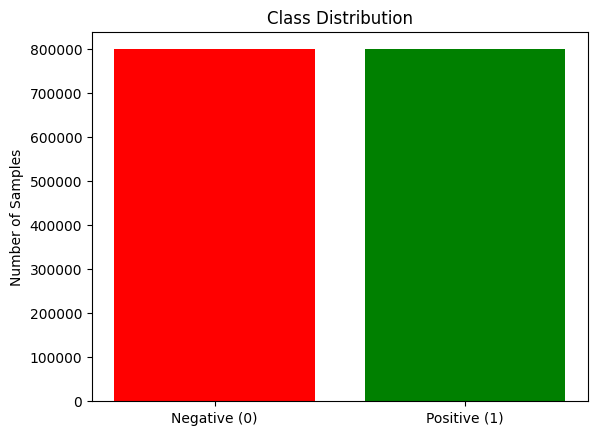

In [7]:
unique, counts = np.unique(Y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} samples ({count/len(Y)*100:.1f}%)")

import matplotlib.pyplot as plt

plt.bar(['Negative (0)', 'Positive (1)'], counts, color=['red', 'green'])
plt.title('Class Distribution')
plt.ylabel('Number of Samples')
plt.show()

### Preprocessing of Data

In [12]:
def lowercase(X):
    return [text.lower() for text in X]


def remove_noise(X):
    cleaned = []
    for text in X:
        text = re.sub(r'http\S+', '', text)   # URLs
        text = re.sub(r'<.*?>', '', text)      # HTML tags
        cleaned.append(text)
    return cleaned


def tokenize(X):
    tweet_tok = TweetTokenizer(strip_handles=True, reduce_len=True)
    return [tweet_tok.tokenize(text) for text in X]


def remove_stopwords(X):
    negation = {'no', 'nor', 'not'}
    stopwords = set(w for w in nltk.corpus.stopwords.words('english')
                    if w not in negation and "n't" not in w)
    return [[w for w in tokens if w not in stopwords] for tokens in X]


def remove_punctuation(X):
    punct = set(string.punctuation)
    return [[w for w in tokens if w not in punct] for tokens in X]


def lemmatize(X):
    lemmatizer = WordNetLemmatizer()
    result = []
    for tokens in X:
        pos_tags = nltk.pos_tag(tokens)
        lemmas = [lemmatizer.lemmatize(w, pos=get_wordnet_pos(t))
                  for w, t in pos_tags]
        result.append(lemmas)
    return result

def get_wordnet_pos(treebank_tag):
        if treebank_tag.startswith('J'):
            return 'a'
        elif treebank_tag.startswith('V'):
            return 'v'
        elif treebank_tag.startswith('N'):
            return 'n'
        elif treebank_tag.startswith('R'):
            return 'r'
        else:
            return 'n'

def vectorize(X, max_vocab=50000):
    tokenizer = Tokenizer(num_words=max_vocab)
    tokenizer.fit_on_texts(X)
    X_vectorized = tokenizer.texts_to_sequences(X)
    return X_vectorized, tokenizer

def pad(X_vectorized, max_length=20):
    return pad_sequences(X_vectorized, maxlen=max_length,
                         padding='post', truncating='post')

In [9]:
print('\nOriginal :')
print(X[index])

X = lowercase(X)
X = remove_noise(X)
print("\nDenoising:")
print(X[index])

X = tokenize(X)
print('\nTokenized :')
print(X[index])

X = remove_stopwords(X)
print("\nX_without_stopwords:")
print(X[index])

X = remove_punctuation(X)
print("\nX_no_punct:")
print(X[index])

X = lemmatize(X)
print("\nX_lemmatized:")
print(X[index])


X_clean = [" ".join(tokens) for tokens in X]


Original :
I am in pain. My back and sides hurt. Not to mention crying is made of fail. 

Denoising:
i am in pain. my back and sides hurt. not to mention crying is made of fail. 

Tokenized :
['i', 'am', 'in', 'pain', '.', 'my', 'back', 'and', 'sides', 'hurt', '.', 'not', 'to', 'mention', 'crying', 'is', 'made', 'of', 'fail', '.']

X_without_stopwords:
['pain', '.', 'back', 'sides', 'hurt', '.', 'not', 'mention', 'crying', 'made', 'fail', '.']

X_no_punct:
['pain', 'back', 'sides', 'hurt', 'not', 'mention', 'crying', 'made', 'fail']

X_lemmatized:
['pain', 'back', 'side', 'hurt', 'not', 'mention', 'cry', 'make', 'fail']


In [13]:
X_vectorized, tok = vectorize(X_clean)      # list of integer sequences + tokenizer
X_padded      = pad(X_vectorized)              # numpy array, shape (N, 20)

In [14]:
print("\nX_vectorized:")
print(X_vectorized[index])
print("\nX_padded:")
print(X_padded[index])


X_vectorized:
[403, 17, 525, 137, 3, 774, 238, 22, 356]

X_padded:
[403  17 525 137   3 774 238  22 356   0   0   0   0   0   0   0   0   0
   0   0]


In [15]:
# Vocabulary size (no. of most frequent tokens) to consider

max_vocab=50000

In [17]:
total_length = 0
for sentence in X_vectorized:
  total_length += len(sentence)

print('Average length of tweets = ' + str(total_length / len(X_vectorized)))

Average length of tweets = 7.21794


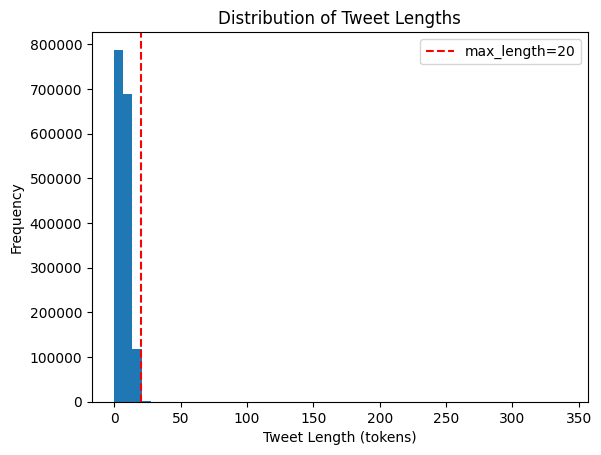

Tweets fully covered by max_length=20: 99.8%


In [18]:
import matplotlib.pyplot as plt

lengths = [len(seq) for seq in X_vectorized]
plt.hist(lengths, bins=50)
plt.axvline(x=20, color='red', linestyle='--', label='max_length=20')
plt.xlabel('Tweet Length (tokens)')
plt.ylabel('Frequency')
plt.title('Distribution of Tweet Lengths')
plt.legend()
plt.show()

# Coverage check
covered = sum(1 for l in lengths if l <= 20) / len(lengths) * 100
print(f"Tweets fully covered by max_length=20: {covered:.1f}%")

max_length=20

### Building Model

In [38]:
model = tf.keras.models.Sequential()

model.add(Embedding(max_vocab, 100, trainable=True))

model.add(Bidirectional(LSTM(64, return_sequences=True)))

model.add(Dropout(0.5))

model.add(Bidirectional(LSTM(32)))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

In [40]:
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=['accuracy']
             )

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split (X_padded,Y.reshape(Y.shape[0],1),test_size=0.05)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1520000, 20)
(80000, 20)
(1520000, 1)
(80000, 1)


In [24]:
model.fit(
    X_train, 
    Y_train, 
    batch_size=256, 
    epochs=15, 
    validation_split=0.05, 
    callbacks=[early_stop]
)

Epoch 1/15
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 573s 100ms/step - accuracy: 0.7739 - loss: 0.4702 - val_accuracy: 0.8038 - val_loss: 0.4220
Epoch 2/15
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 549s 97ms/step - accuracy: 0.8199 - loss: 0.3977 - val_accuracy: 0.8059 - val_loss: 0.4174
Epoch 3/15
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 506s 90ms/step - accuracy: 0.8345 - loss: 0.3705 - val_accuracy: 0.8067 - val_loss: 0.4218
Epoch 4/15
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 483s 86ms/step - accuracy: 0.8489 - loss: 0.3411 - val_accuracy: 0.8042 - val_loss: 0.4441
Epoch 5/15
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 486s 86ms/step - accuracy: 0.8634 - loss: 0.3115 - val_accuracy: 0.7984 - val_loss: 0.4726


In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 100)        │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 20, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,377,285 (58.66 MB)

 Trainable params: 5,125,761 (19.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,251,524 (39.11 MB)

In [26]:
model.evaluate(X_test,Y_test)

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8104 - loss: 0.4135


[0.4138975441455841, 0.8111000061035156]

### Metrics

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step


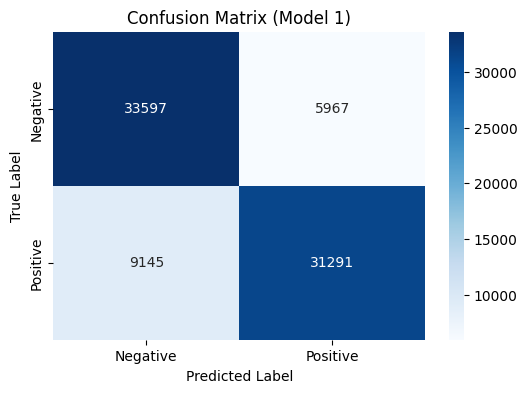

              precision    recall  f1-score   support

    Negative       0.79      0.85      0.82     39564
    Positive       0.84      0.77      0.81     40436

    accuracy                           0.81     80000
   macro avg       0.81      0.81      0.81     80000
weighted avg       0.81      0.81      0.81     80000



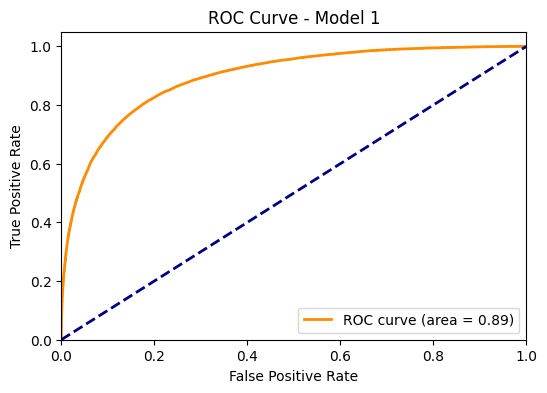

In [27]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

Y_pred_prob = model.predict(X_test)
Y_pred = (Y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix (Model 1)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(Y_test, Y_pred, target_names=['Negative', 'Positive']))

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model 1')
plt.legend(loc="lower right")
plt.show()

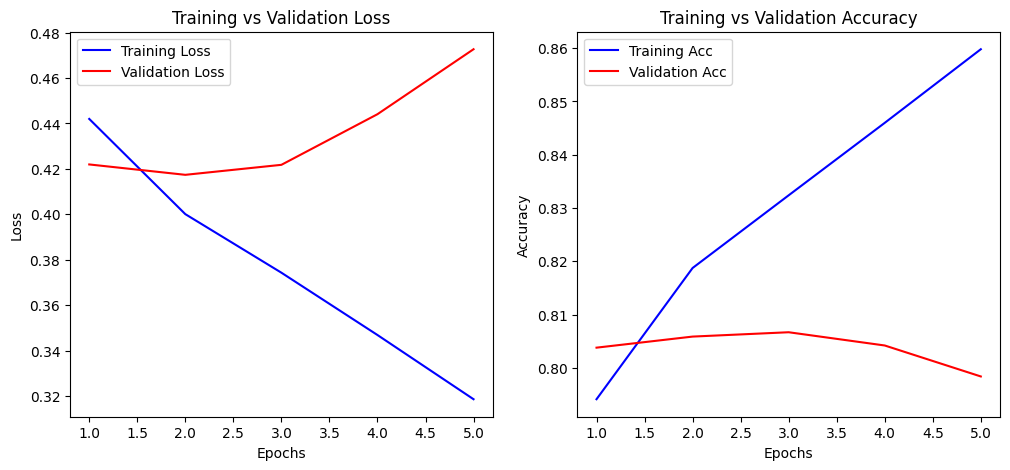

In [33]:

history_dict = model.history.history
epochs = range(1, len(history_dict['loss']) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['loss'], 'b', label='Training Loss')
plt.plot(epochs, history_dict['val_loss'], 'r', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['accuracy'], 'b', label='Training Acc')
plt.plot(epochs, history_dict['val_accuracy'], 'r', label='Validation Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()